In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/2"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第2章 確率 (Probabilities)
## 2.3 ガウス分布 (The Gaussian Distribution)

本ノートブックは、教科書『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』(Bishop & Bishop, 2024) の **第2章 2.3節「ガウス分布 (The Gaussian Distribution)」** を完全網羅し、厳密な数理導出、対話的シミュレーション、および教科書図版（Figure 2.8, 2.9, 2.10, 2.11）の忠実な再現を提供するものです。

ガウス分布（正規分布: Normal Distribution）は、確率統計学および機械学習・深層学習において **最も基本的かつ広く用いられる連続確率分布** です。中心極限定理による普遍性、解析的扱いやすさ（積分が閉じた形で実行可能）、エントロピー最大性など、数学的にも実用的にも極めて重要な性質を備えています。

本ノートブックでは、1次元ガウス分布の基礎性質から始まり、平均・分散のモーメント導出、最尤推定量の解析解、最尤推定量が有限サンプルで生じる「バイアス」の幾何学的・数理的解明、そして第1章の多項式フィッティングを確率論的観点から定式化する「確率的線形回帰」までを徹底的に探究します。

---

### 目次
1. [2.3 ガウス分布の基礎 (The Gaussian Distribution)](#sec_2_3)
   - 1次元ガウス分布の定義 (式 2.49)
   - 精度パラメータ $\beta$ (式 2.50)
   - 規格化条件の極座標重積分による完全証明 (式 2.51)
   - 変曲点と幾何学的形状 (Figure 2.8)
2. [2.3.1 平均と分散 (Mean and variance)](#sec_2_3_1)
   - 1次モーメント（期待値 $\mathbb{E}[x] = \mu$）の置換積分導出 (式 2.52)
   - 2次モーメント（$\mathbb{E}[x^2] = \mu^2 + \sigma^2$）の部分積分導出 (式 2.53)
   - 分散 $\text{var}[x] = \sigma^2$ と標準偏差 $\sigma$ (式 2.54)
   - 対称性、最頻値 (Mode)、中央値 (Median)
3. [2.3.2 尤度関数 (Likelihood function)](#sec_2_3_2)
   - i.i.d. 観測データと同時確率密度 (式 2.55, Figure 2.9)
   - 対数尤度関数の展開 (式 2.56)
   - パラメータ $\mu, \sigma^2$ に関する勾配と最尤推定量 $\mu_{\mathrm{ML}}, \sigma^2_{\mathrm{ML}}$ の閉形式導出 (式 2.57, 2.58)
   - 対数尤度曲面の対話的可視化
4. [2.3.3 最尤推定のバイアス (Bias of maximum likelihood)](#sec_2_3_3)
   - 推定量の不偏性とバイアスの定義
   - 標本平均 $\mu_{\mathrm{ML}}$ の不偏性の証明 (式 2.59)
   - 標本分散 $\sigma^2_{\mathrm{ML}}$ の期待値と過小評価バイアス $\frac{N-1}{N}\sigma^2$ の厳密証明 (式 2.60)
   - なぜ最尤推定の分散は過小評価されるのか？幾何学的解明 (Figure 2.10)
   - 真の平均を用いた分散推定量 $\widehat{\sigma}^2$ (式 2.62)
   - 不偏分散推定量 $\widetilde{\sigma}^2$（ベッセルの補正）(式 2.63)
   - モンテカルロシミュレーションによるバイアス検証
5. [2.3.4 線形回帰 (Linear regression)](#sec_2_3_4)
   - ガウスノイズを伴う条件付き確率モデル $p(t \mid x, \mathbf{w}, \sigma^2)$ (式 2.64, Figure 2.11)
   - 同時尤度と対数尤度の最大化 (式 2.65, 2.66)
   - 二乗和誤差最小化と最尤推定の数学的等価性 (式 2.67)
   - 重みベクトル $\mathbf{w}_{\mathrm{ML}}$ の正規方程式解とノイズ分散推定量 $\sigma^2_{\mathrm{ML}}$ (式 2.67, 2.68)
   - 予測分布 $p(t \mid x, \mathbf{w}_{\mathrm{ML}}, \sigma^2_{\mathrm{ML}})$ による不確実性の定量化 (式 2.69)
6. [深層学習との接続とまとめ](#sec_summary)


In [1]:
# 環境セットアップと共通モジュールのインポート
import sys, os
sys.path.append(os.path.abspath('../'))

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats

from common.plot_utils import setup_style, save_plot
from common.probability import (
    Gaussian1D,
    gaussian_maximum_likelihood,
    simulate_gaussian_mle_bias,
    GaussianLinearRegression
)

setup_style()
print("環境セットアップ完了: common.probability から Section 2.3 ユーティリティを正常に読み込みました。")


環境セットアップ完了: common.probability から Section 2.3 ユーティリティを正常に読み込みました。


<a id="sec_2_3"></a>
---
## 2.3 ガウス分布の基礎 (The Gaussian Distribution)

### ガウス分布の確率密度関数
1つの連続実数値変数 $x \in (-\infty, \infty)$ に対する **ガウス分布（正規分布）** の確率密度関数は、平均パラメータ $\mu \in \mathbb{R}$ と分散パラメータ $\sigma^2 > 0$（標準偏差 $\sigma > 0$）によって次のように定義されます：

$$
\mathcal{N}(x \mid \mu, \sigma^2) = \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left\{ -\frac{1}{2\sigma^2}(x - \mu)^2 \right\} \tag{2.49}
$$

### 精度 (Precision) パラメータ $\beta$ による表現
統計物理学やベイズ機械学習では、分散 $\sigma^2$ の逆数として **精度 (Precision)** $\beta$:
$$\beta \equiv \frac{1}{\sigma^2}$$
を導入すると、数式がよりシンプルで線形性を保ちやすくなります。精度 $\beta$ を用いたガウス分布の表現は以下の通りです：

$$
\mathcal{N}(x \mid \mu, \beta^{-1}) = \left( \frac{\beta}{2\pi} \right)^{1/2} \exp\left\{ -\frac{\beta}{2}(x - \mu)^2 \right\} \tag{2.50}
$$

分散 $\sigma^2$ が小さい（＝不確実性が小さい）とき、精度 $\beta$ は非常に大きくなり、確率密度は平均 $\mu$ の周りに急峻に集中します。

---

### 規格化条件の厳密証明 (式 2.51)
確率密度の公理を満たすためには、全空間積分の値が厳密に 1 でなければなりません：

$$
\int_{-\infty}^\infty \mathcal{N}(x \mid \mu, \sigma^2) dx = 1 \tag{2.51}
$$

#### [証明のステップ]
変数変換 $u = \frac{x - \mu}{\sigma}$（$dx = \sigma du$）を施すと、積分の核は標準ガウス積分に帰着されます：
$$
I = \int_{-\infty}^\infty \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left\{ -\frac{1}{2\sigma^2}(x - \mu)^2 \right\} dx = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^\infty \exp\left\{ -\frac{u^2}{2} \right\} du
$$
ここで、ガウス積分 $J = \int_{-\infty}^\infty \exp\left\{ -u^2/2 \right\} du$ を求めるため、その2乗 $J^2$ を2次元平面重積分として評価します：
$$
J^2 = \left( \int_{-\infty}^\infty \exp\left\{ -\frac{u^2}{2} \right\} du \right)\left( \int_{-\infty}^\infty \exp\left\{ -\frac{v^2}{2} \right\} dv \right) = \int_{-\infty}^\infty \int_{-\infty}^\infty \exp\left\{ -\frac{u^2 + v^2}{2} \right\} du dv
$$
極座標変換 $u = r\cos\theta, v = r\sin\theta$（ヤコビアン $du dv = r dr d\theta$、$r \in [0, \infty), \theta \in [0, 2\pi)$）を行うと：
$$
J^2 = \int_0^{2\pi} d\theta \int_0^\infty r \exp\left\{ -\frac{r^2}{2} \right\} dr = 2\pi \left[ -\exp\left\{ -\frac{r^2}{2} \right\} \right]_0^\infty = 2\pi (0 - (-1)) = 2\pi
$$
両辺の正の平方根をとることで $J = \sqrt{2\pi}$ が得られます。
したがって：
$$
I = \frac{1}{\sqrt{2\pi}} \cdot \sqrt{2\pi} = 1 \quad \blacksquare
$$

---

### ガウス分布の形状と変曲点 (Figure 2.8)
ガウス分布の確率密度関数 $\mathcal{N}(x \mid \mu, \sigma^2)$ の形状を微分して解析します。
$$
\frac{d}{dx} \mathcal{N}(x \mid \mu, \sigma^2) = -\frac{x - \mu}{\sigma^2} \mathcal{N}(x \mid \mu, \sigma^2)
$$
1階微分がゼロとなるのは $x = \mu$ のみであり、ここで密度は最大値 $\frac{1}{(2\pi\sigma^2)^{1/2}}$ をとります。
さらに2階微分を計算すると：
$$
\frac{d^2}{dx^2} \mathcal{N}(x \mid \mu, \sigma^2) = \left( \frac{(x - \mu)^2 - \sigma^2}{\sigma^4} \right) \mathcal{N}(x \mid \mu, \sigma^2)
$$
2階微分がゼロとなる変曲点（Inflection Points）は：
$$(x - \mu)^2 = \sigma^2 \implies x = \mu \pm \sigma$$
変曲点間の距離はちょうど **$2\sigma$** となります。この特徴は、教科書 **Figure 2.8** に示されています。


### 教科書図版の再現: Figure 2.8
以下の図は、平均 $\mu$、標準偏差 $\sigma$ を持つ1次元ガウス分布の密度曲線、平均 $\mu$ の位置、および変曲点間の幅 $2\sigma$ を忠実に再現したものです。

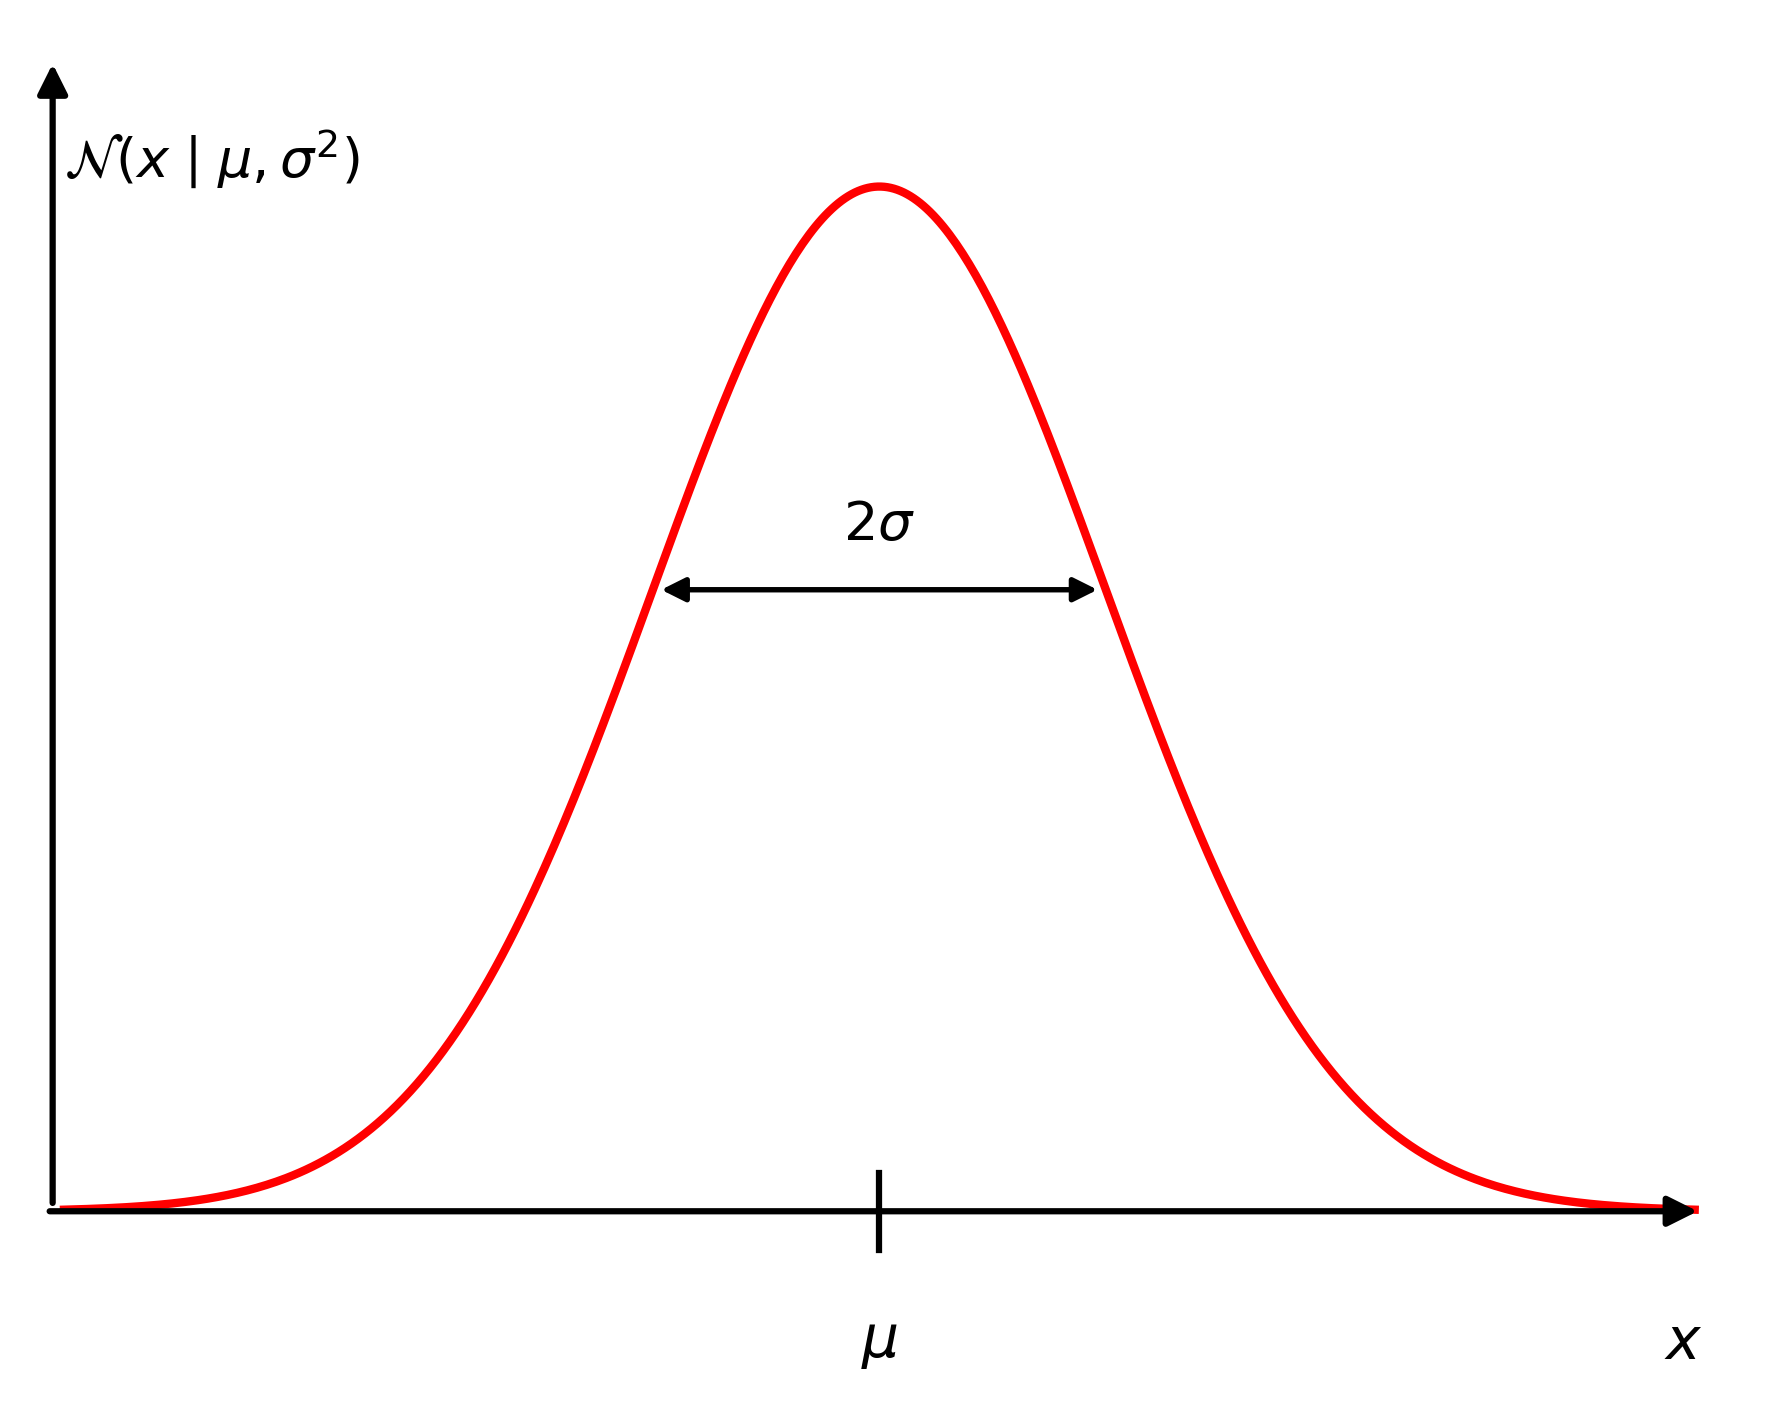

In [2]:
# Figure 2.8 の表示と確認
from IPython.display import Image, display
fig2_08_path = "../result/fig2_08_gaussian_distribution.png"
if os.path.exists(fig2_08_path):
    display(Image(filename=fig2_08_path, width=500))
else:
    from scripts.generate_ch2_3_figures import generate_figure_2_8
    generate_figure_2_8()
    display(Image(filename=fig2_08_path, width=500))


In [3]:
# Gaussian1D クラスによる正規化と変曲点の数値検証
gauss = Gaussian1D(mu=2.0, sigma2=1.5**2)

# 1. 規格化積分の数値検証
integral_val, abserr = integrate.quad(gauss.pdf, -np.inf, np.inf)
print(f"全空間積分の数値計算結果: {integral_val:.8f} (誤差: {abserr:.2e})")

# 2. 変曲点における2階微分のゼロクロス検証
eps = 1e-4
x_inflec_plus = gauss.mu + gauss.sigma
d2_val = (gauss.pdf(x_inflec_plus + eps) - 2 * gauss.pdf(x_inflec_plus) + gauss.pdf(x_inflec_plus - eps)) / (eps**2)
print(f"x = mu + sigma ({x_inflec_plus:.2f}) における数値2階微分値: {d2_val:.2e} (理論値: 0)")

# 3. 1σ, 2σ, 3σ 区間の確率質量（累積分布）
p_1sigma = gauss.cdf(gauss.mu + gauss.sigma) - gauss.cdf(gauss.mu - gauss.sigma)
p_2sigma = gauss.cdf(gauss.mu + 2 * gauss.sigma) - gauss.cdf(gauss.mu - 2 * gauss.sigma)
p_3sigma = gauss.cdf(gauss.mu + 3 * gauss.sigma) - gauss.cdf(gauss.mu - 3 * gauss.sigma)
print(f"μ ± 1σ 含有確率: {p_1sigma * 100:.2f}% (理論値: 68.27%)")
print(f"μ ± 2σ 含有確率: {p_2sigma * 100:.2f}% (理論値: 95.45%)")
print(f"μ ± 3σ 含有確率: {p_3sigma * 100:.2f}% (理論値: 99.73%)")


全空間積分の数値計算結果: 1.00000000 (誤差: 6.18e-09)
x = mu + sigma (3.50) における数値2階微分値: -2.78e-09 (理論値: 0)
μ ± 1σ 含有確率: 68.27% (理論値: 68.27%)
μ ± 2σ 含有確率: 95.45% (理論値: 95.45%)
μ ± 3σ 含有確率: 99.73% (理論値: 99.73%)


<a id="sec_2_3_1"></a>
---
### 2.3.1 平均と分散 (Mean and variance)

ガウス分布 $\mathcal{N}(x \mid \mu, \sigma^2)$ のパラメータ $\mu$ と $\sigma^2$ が、それぞれ分布の **期待値（平均）** および **分散** に厳密に一致することを数理的に証明します。

#### 1. 期待値（1次モーメント）の導出 (式 2.52)
連続変数の期待値の定義より：
$$
\mathbb{E}[x] = \int_{-\infty}^\infty \mathcal{N}(x \mid \mu, \sigma^2) \, x \, dx \tag{2.52}
$$
変数変換 $y = x - \mu$（$x = y + \mu$、$dx = dy$）を適用します：
$$
\mathbb{E}[x] = \int_{-\infty}^\infty \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left\{ -\frac{y^2}{2\sigma^2} \right\} (y + \mu) \, dy
$$
これを2つの積分に分解します：
$$
\mathbb{E}[x] = \frac{1}{(2\pi\sigma^2)^{1/2}} \underbrace{\int_{-\infty}^\infty y \exp\left\{ -\frac{y^2}{2\sigma^2} \right\} dy}_{\text{奇関数の積分}} + \mu \underbrace{\int_{-\infty}^\infty \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left\{ -\frac{y^2}{2\sigma^2} \right\} dy}_{\text{規格化条件} = 1}
$$
第1項の被積分関数 $g(y) = y \exp\left( -y^2 / 2\sigma^2 \right)$ は原点に関して対称な **奇関数**（$g(-y) = -g(y)$）であり、対称区間 $(-\infty, \infty)$ での積分は厳密に 0 です。
第2項はガウス分布の全確率積分であるため 1 となります。したがって：
$$
\mathbb{E}[x] = 0 + \mu \cdot 1 = \mu \tag{2.52}
$$
これにより、パラメータ $\mu$ が分布の期待値であることが示されました。

---

#### 2. 2次モーメントの導出 (式 2.53)
次に、2次モーメント $\mathbb{E}[x^2]$ を求めます：
$$
\mathbb{E}[x^2] = \int_{-\infty}^\infty \mathcal{N}(x \mid \mu, \sigma^2) \, x^2 \, dx
$$
同様に $x = y + \mu$ と変数変換すると、$x^2 = y^2 + 2\mu y + \mu^2$ と展開できます：
$$
\mathbb{E}[x^2] = \int_{-\infty}^\infty \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left\{ -\frac{y^2}{2\sigma^2} \right\} (y^2 + 2\mu y + \mu^2) \, dy
$$
奇関数項 $\int y \exp(\dots) dy = 0$ であるため、交差項は消滅します：
$$
\mathbb{E}[x^2] = \frac{1}{(2\pi\sigma^2)^{1/2}} \int_{-\infty}^\infty y^2 \exp\left\{ -\frac{y^2}{2\sigma^2} \right\} dy + \mu^2
$$
残る積分 $K = \int_{-\infty}^\infty y^2 \exp\left\{ -y^2 / (2\sigma^2) \right\} dy$ に対して、部分積分法（$u = y$, $v' = y \exp\left\{ -y^2 / 2\sigma^2 \right\} \implies v = -\sigma^2 \exp\left\{ -y^2 / 2\sigma^2 \right\}$）を適用します：
$$
K = \left[ -y \sigma^2 \exp\left\{ -\frac{y^2}{2\sigma^2} \right\} \right]_{-\infty}^\infty - \int_{-\infty}^\infty (1) \left( -\sigma^2 \exp\left\{ -\frac{y^2}{2\sigma^2} \right\} \right) dy
$$
境界値項は極限でゼロになり、右側の積分はガウス積分 $\sqrt{2\pi}\sigma$ となるため：
$$
K = 0 + \sigma^2 \int_{-\infty}^\infty \exp\left\{ -\frac{y^2}{2\sigma^2} \right\} dy = \sigma^2 \cdot \sqrt{2\pi}\sigma = (2\pi)^{1/2}\sigma^3
$$
これを元の式に代入すると：
$$
\mathbb{E}[x^2] = \frac{(2\pi)^{1/2}\sigma^3}{(2\pi\sigma^2)^{1/2}} + \mu^2 = \sigma^2 + \mu^2 \tag{2.53}
$$

---

#### 3. 分散の導出 (式 2.54)
分散は 2次モーメントと期待値の2乗の差として得られます：
$$
\text{var}[x] = \mathbb{E}[x^2] - (\mathbb{E}[x])^2 = (\mu^2 + \sigma^2) - \mu^2 = \sigma^2 \tag{2.54}
$$
これより、パラメータ $\sigma^2$ が厳密に分散であり、$\sigma$ が標準偏差であることが証明されました。

また、ガウス分布は単峰性（Unimodal）かつ平均 $\mu$ に関して左右完全対称であるため、**平均 (Mean)**、**最頻値 (Mode)**、**中央値 (Median)** のすべてが一致します：
$$\text{Mean} = \text{Mode} = \text{Median} = \mu$$


In [4]:
# モーメントの解析解とモンテカルロ推定の比較
mu_val, sigma2_val = 3.5, 2.25
gauss_model = Gaussian1D(mu=mu_val, sigma2=sigma2_val)

# モンテカルロサンプリング
N_mc = 500_000
samples = gauss_model.sample(size=N_mc, seed=123)

mc_mean = np.mean(samples)
mc_second_moment = np.mean(samples**2)
mc_var = np.var(samples, ddof=1)

print(f"=== ガウス分布のモーメント検証 (mu={mu_val}, sigma2={sigma2_val}) ===")
print(f"期待値 E[x]:    理論値 = {gauss_model.mean:.4f}, モンテカルロ = {mc_mean:.4f}")
print(f"2次モーメント E[x^2]: 理論値 = {mu_val**2 + sigma2_val:.4f}, モンテカルロ = {mc_second_moment:.4f}")
print(f"分散 var[x]:    理論値 = {gauss_model.variance:.4f}, モンテカルロ = {mc_var:.4f}")


=== ガウス分布のモーメント検証 (mu=3.5, sigma2=2.25) ===
期待値 E[x]:    理論値 = 3.5000, モンテカルロ = 3.5002
2次モーメント E[x^2]: 理論値 = 14.5000, モンテカルロ = 14.5001
分散 var[x]:    理論値 = 2.2500, モンテカルロ = 2.2486


<a id="sec_2_3_2"></a>
---
### 2.3.2 尤度関数 (Likelihood function)

機械学習における中心課題は、「観測されたデータから、その背後にある生成分布のパラメータをどのように推定するか」です。

#### 独立同配分 (i.i.d.) 仮定と尤度関数 (式 2.55)
未知のガウス分布 $\mathcal{N}(x \mid \mu, \sigma^2)$ から互いに独立かつ同一の分布に従って生成された（i.i.d.）データセット $\mathbf{x} = (x_1, \dots, x_N)^T$ が得られたと仮定します。
独立事象の乗法定理より、このデータセット全体の同時確率密度は、各サンプルの確率密度の積で表されます。これをパラメータ $\mu, \sigma^2$ の関数とみなしたものを **尤度関数 (Likelihood Function)** と呼びます：

$$
p(\mathbf{x} \mid \mu, \sigma^2) = \prod_{n=1}^N \mathcal{N}(x_n \mid \mu, \sigma^2) \tag{2.55}
$$

この尤度関数の直感的な幾何構造を示したものが、教科書 **Figure 2.9** です。各観測データ点 $x_n$ における確率密度曲線の高さ $\mathcal{N}(x_n \mid \mu, \sigma^2)$ を掛け合わせたものが同時尤度となります。


### 教科書図版の再現: Figure 2.9
以下の図は、観測データ点 $x_n$（灰色の点）と、ガウス確率密度曲線上の対応する高さ $\mathcal{N}(x_n \mid \mu, \sigma^2)$（緑色の垂直線と青色の点）を示したものです。尤度関数はこれらすべての高さの総乗として定義されます。

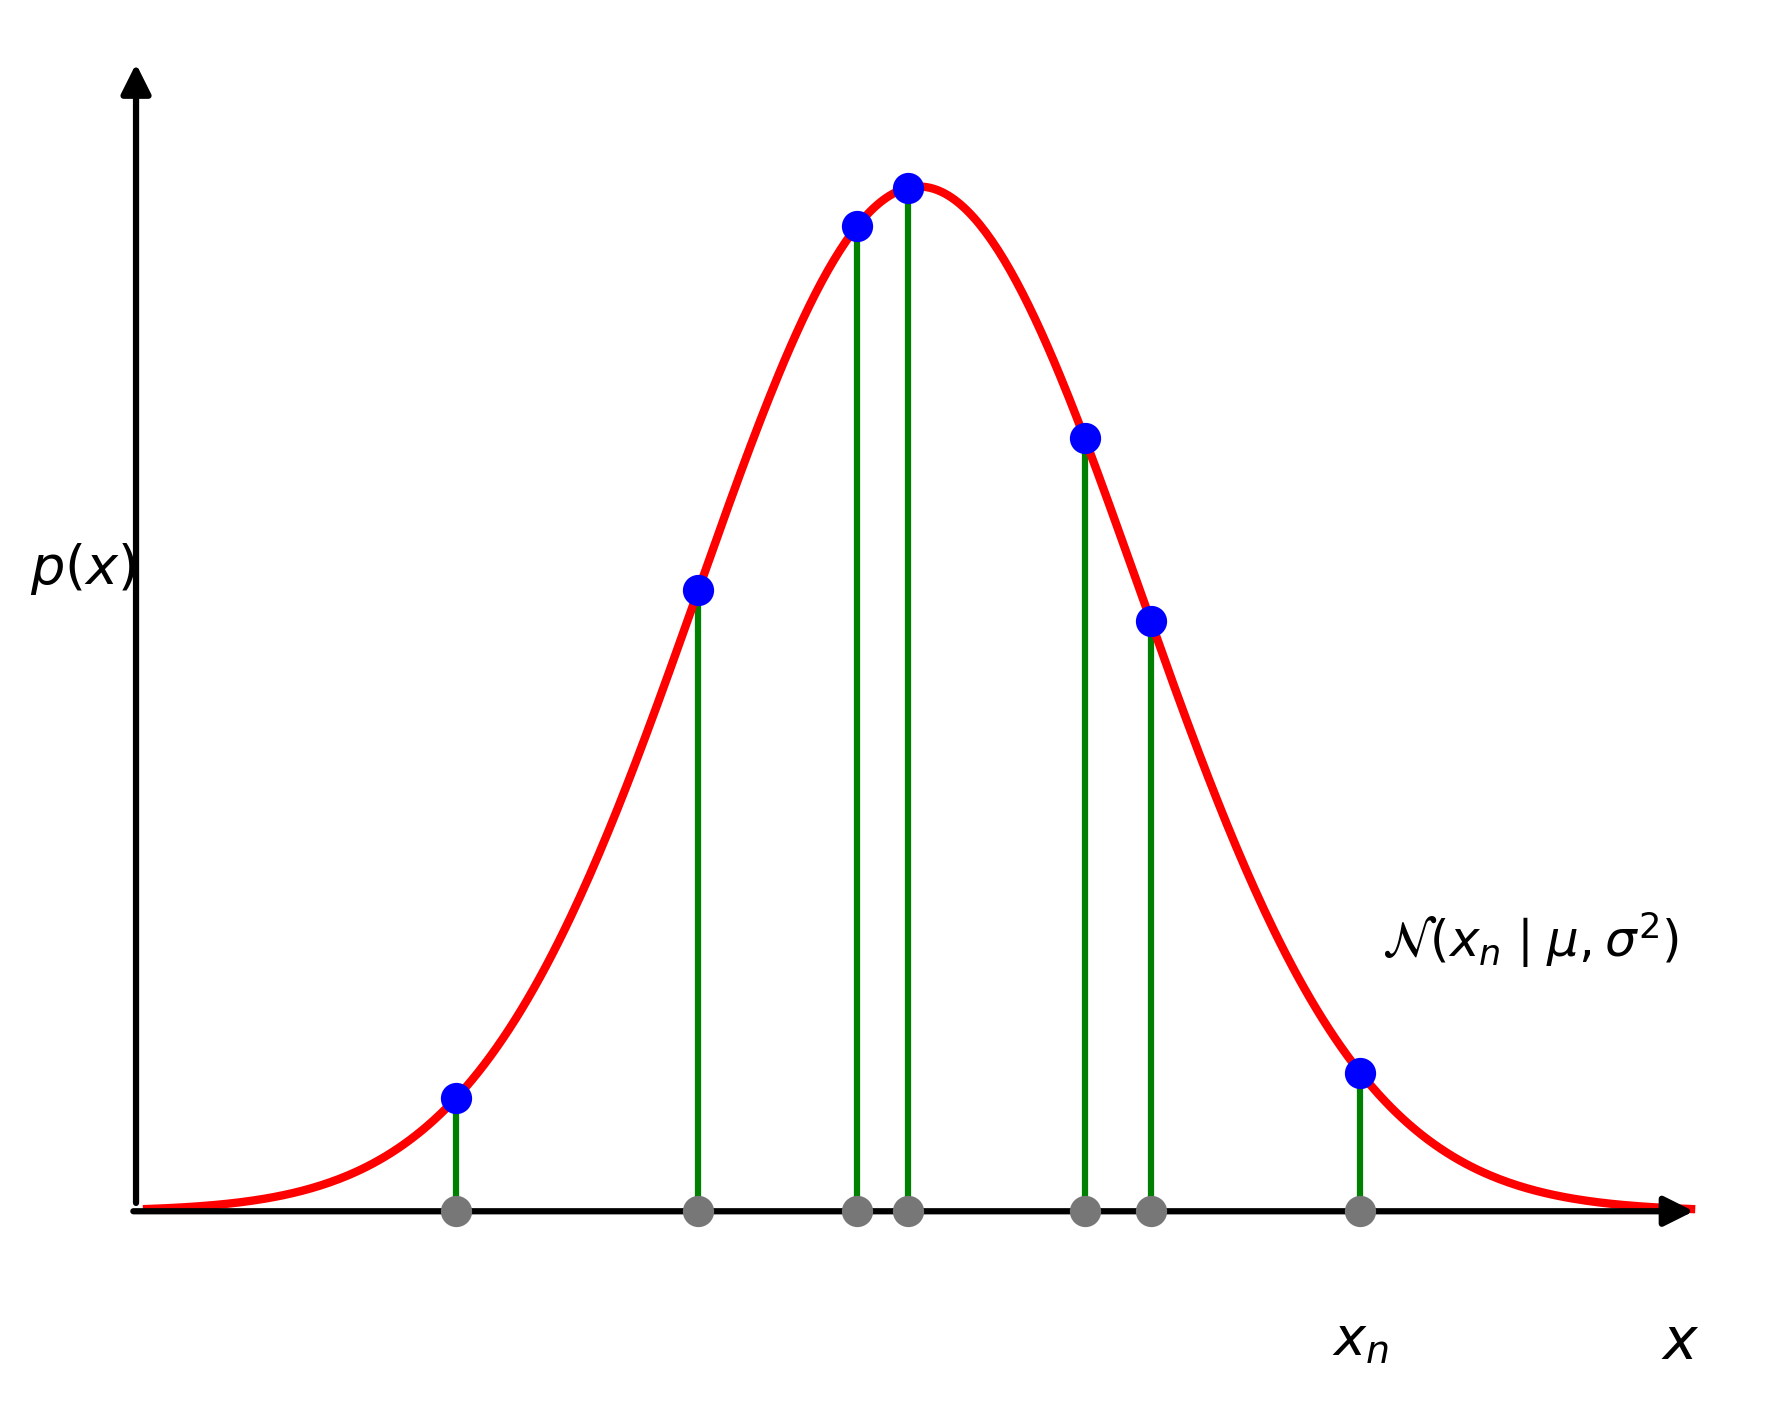

In [5]:
# Figure 2.9 の表示と確認
fig2_09_path = "../result/fig2_09_gaussian_likelihood.png"
if os.path.exists(fig2_09_path):
    display(Image(filename=fig2_09_path, width=500))
else:
    from scripts.generate_ch2_3_figures import generate_figure_2_9
    generate_figure_2_9()
    display(Image(filename=fig2_09_path, width=500))


#### 対数尤度関数 (式 2.56)
積の形の尤度関数を直接最大化することは、数値的なアンダーフロー（微小な確率の掛け合わせによるゼロ落ち）や微分の積の法則による複雑化を招きます。
そこで、単調増加関数である自然対数をとった **対数尤度関数 (Log-Likelihood Function)** を用います：

$$
\ln p(\mathbf{x} \mid \mu, \sigma^2) = \sum_{n=1}^N \ln \mathcal{N}(x_n \mid \mu, \sigma^2)
$$
式 (2.49) の対数をとると：
$$
\ln \mathcal{N}(x_n \mid \mu, \sigma^2) = -\frac{1}{2} \ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}(x_n - \mu)^2 = -\frac{1}{2}\ln(2\pi) - \frac{1}{2}\ln\sigma^2 - \frac{1}{2\sigma^2}(x_n - \mu)^2
$$
$N$ 個のサンプルの総和をとることで、教科書 **式 (2.56)** が導かれます：

$$
\ln p(\mathbf{x} \mid \mu, \sigma^2) = -\frac{1}{2\sigma^2} \sum_{n=1}^N (x_n - \mu)^2 - \frac{N}{2} \ln \sigma^2 - \frac{N}{2} \ln(2\pi) \tag{2.56}
$$

---

#### 最尤推定量 $\mu_{\mathrm{ML}}$ の導出 (式 2.57)
対数尤度関数を $\mu$ に関して微分し、ゼロとおきます：
$$
\frac{\partial}{\partial \mu} \ln p(\mathbf{x} \mid \mu, \sigma^2) = \frac{1}{\sigma^2} \sum_{n=1}^N (x_n - \mu) = 0
$$
$\sigma^2 > 0$ であるため：
$$
\sum_{n=1}^N x_n - N\mu = 0 \implies \mu_{\mathrm{ML}} = \frac{1}{N} \sum_{n=1}^N x_n \tag{2.57}
$$
すなわち、ガウス分布の平均パラメータに対する最尤推定量は、観測データの相加平均である **標本平均 (Sample Mean)** に厳密に一致します。

---

#### 最尤推定量 $\sigma^2_{\mathrm{ML}}$ の導出 (式 2.58)
続いて、対数尤度関数を分散パラメータ $\sigma^2$ に関して微分し、ゼロとおきます：
$$
\frac{\partial}{\partial \sigma^2} \ln p(\mathbf{x} \mid \mu, \sigma^2) = \frac{1}{2(\sigma^2)^2} \sum_{n=1}^N (x_n - \mu)^2 - \frac{N}{2\sigma^2} = 0
$$
両辺に $2(\sigma^2)^2$ を乗じると：
$$
\sum_{n=1}^N (x_n - \mu)^2 - N\sigma^2 = 0
$$
ここで $\mu$ として最尤推定量 $\mu_{\mathrm{ML}}$ を代入することにより、分散の最尤解が得られます：

$$
\sigma_{\mathrm{ML}}^2 = \frac{1}{N} \sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2 \tag{2.58}
$$
これは、標本平均 $\mu_{\mathrm{ML}}$ の周りで計算された **標本分散 (Sample Variance)** に一致します。


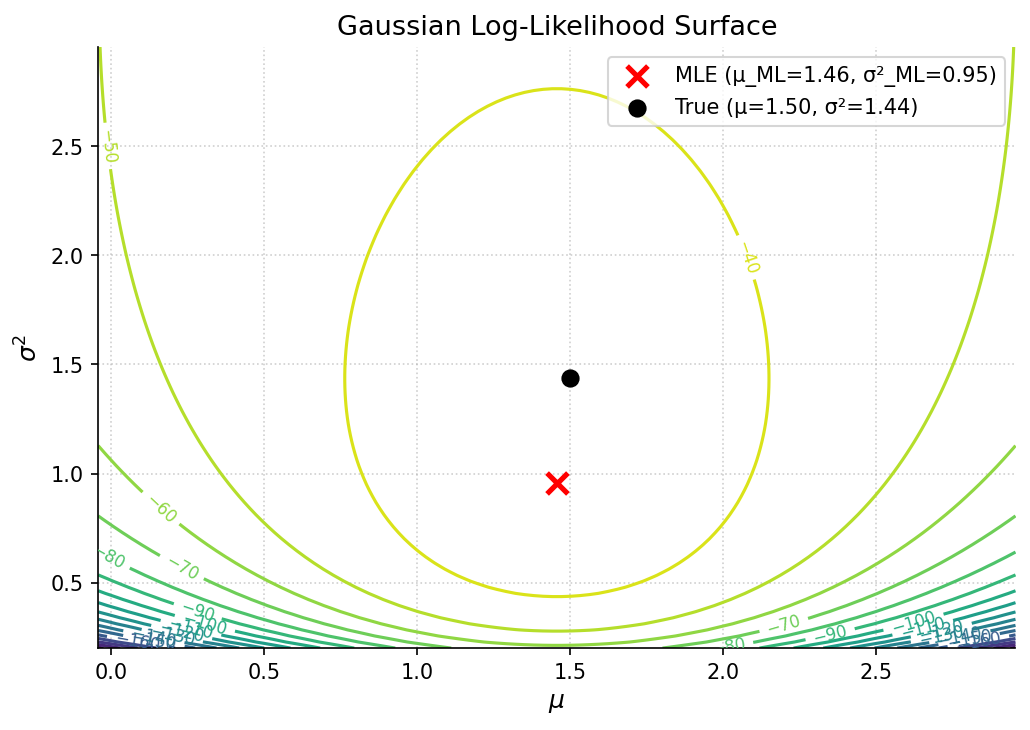

In [6]:
# 対数尤度曲面の可視化と最尤推定量のプロット
rng = np.random.default_rng(42)
true_mu_data, true_sigma_data = 1.5, 1.2
data_samples = rng.normal(loc=true_mu_data, scale=true_sigma_data, size=25)

mle_res = gaussian_maximum_likelihood(data_samples)
mu_hat = mle_res["mu_ML"]
sigma2_hat = mle_res["sigma2_ML"]

# グリッドの作成
mu_grid = np.linspace(mu_hat - 1.5, mu_hat + 1.5, 100)
sigma2_grid = np.linspace(max(0.2, sigma2_hat - 1.5), sigma2_hat + 2.0, 100)
MU, SIGMA2 = np.meshgrid(mu_grid, sigma2_grid)

# 対数尤度計算
LL = np.zeros_like(MU)
N = len(data_samples)
for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        s2 = SIGMA2[i, j]
        m = MU[i, j]
        LL[i, j] = -0.5 * np.sum((data_samples - m)**2) / s2 - 0.5 * N * np.log(s2) - 0.5 * N * np.log(2 * np.pi)

plt.figure(figsize=(7, 5), dpi=150)
cs = plt.contour(MU, SIGMA2, LL, levels=20, cmap='viridis')
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter([mu_hat], [sigma2_hat], color='red', marker='x', s=100, linewidth=2.5,
            label=f'MLE (μ_ML={mu_hat:.2f}, σ²_ML={sigma2_hat:.2f})', zorder=5)
plt.scatter([true_mu_data], [true_sigma_data**2], color='black', marker='o', s=60,
            label=f'True (μ={true_mu_data:.2f}, σ²={true_sigma_data**2:.2f})', zorder=5)
plt.xlabel(r'$\mu$', fontsize=12)
plt.ylabel(r'$\sigma^2$', fontsize=12)
plt.title('Gaussian Log-Likelihood Surface', fontsize=13)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


<a id="sec_2_3_3"></a>
---
### 2.3.3 最尤推定のバイアス (Bias of maximum likelihood)

最尤推定法は強力かつ直感的なパラメータ推定法ですが、**有限の標本数 $N$ において系統的な偏り（バイアス: Bias）を生じる** という重大な限界を持ちます。

推定量 $\hat{\theta}$ のバイアスは、推定量の期待値と真の母数 $\theta$ との差として定義されます：
$$\text{Bias}(\hat{\theta}) = \mathbb{E}[\hat{\theta}] - \theta$$
$\mathbb{E}[\hat{\theta}] = \theta$ が成り立つとき、推定量は **不偏 (Unbiased)** であると言います。

---

#### 1. 標本平均 $\mu_{\mathrm{ML}}$ の不偏性 (式 2.59)
標本平均 $\mu_{\mathrm{ML}} = \frac{1}{N}\sum_{n=1}^N x_n$ の期待値を計算します。期待値の線形性より：
$$
\mathbb{E}[\mu_{\mathrm{ML}}] = \mathbb{E}\left[ \frac{1}{N}\sum_{n=1}^N x_n \right] = \frac{1}{N}\sum_{n=1}^N \mathbb{E}[x_n]
$$
各観測点 $x_n$ は真の母平均 $\mu$ を持つ同一分布からサンプリングされているため、$\mathbb{E}[x_n] = \mu$ です：
$$
\mathbb{E}[\mu_{\mathrm{ML}}] = \frac{1}{N} (N \mu) = \mu \tag{2.59}
$$
したがって、ガウス分布の平均に対する最尤推定量 $\mu_{\mathrm{ML}}$ は **不偏推定量** です。

---

#### 2. 標本分散 $\sigma^2_{\mathrm{ML}}$ のバイアスの厳密導出 (式 2.60)
一方、最尤推定量である標本分散 $\sigma^2_{\mathrm{ML}} = \frac{1}{N}\sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2$ の期待値を評価します。

まず、偏差 $(x_n - \mu_{\mathrm{ML}})$ に真の平均 $\mu$ を挿入して分解します：
$$
x_n - \mu_{\mathrm{ML}} = (x_n - \mu) - (\mu_{\mathrm{ML}} - \mu)
$$
この両辺の2乗をとり、データセット全体 $n=1, \dots, N$ で総和をとります：
$$
\sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2 = \sum_{n=1}^N \left\{ (x_n - \mu) - (\mu_{\mathrm{ML}} - \mu) \right\}^2
$$
右辺を展開すると：
$$
= \sum_{n=1}^N (x_n - \mu)^2 - 2 (\mu_{\mathrm{ML}} - \mu) \sum_{n=1}^N (x_n - \mu) + \sum_{n=1}^N (\mu_{\mathrm{ML}} - \mu)^2
$$
ここで、定義より $\sum_{n=1}^N (x_n - \mu) = \sum x_n - N\mu = N(\mu_{\mathrm{ML}} - \mu)$ であるため：
$$
\sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2 = \sum_{n=1}^N (x_n - \mu)^2 - 2 N (\mu_{\mathrm{ML}} - \mu)^2 + N (\mu_{\mathrm{ML}} - \mu)^2 = \sum_{n=1}^N (x_n - \mu)^2 - N (\mu_{\mathrm{ML}} - \mu)^2
$$

この両辺の期待値をとります：
$$
\mathbb{E}\left[ \sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2 \right] = \sum_{n=1}^N \mathbb{E}[(x_n - \mu)^2] - N \mathbb{E}[(\mu_{\mathrm{ML}} - \mu)^2]
$$
第1項は真の分散の定義そのものであり：
$$\mathbb{E}[(x_n - \mu)^2] = \text{var}[x_n] = \sigma^2 \implies \sum_{n=1}^N \mathbb{E}[(x_n - \mu)^2] = N \sigma^2$$
第2項の $\mathbb{E}[(\mu_{\mathrm{ML}} - \mu)^2]$ は、標本平均の分散 $\text{var}[\mu_{\mathrm{ML}}]$ です。
各サンプル $x_n$ の独立性より：
$$
\text{var}[\mu_{\mathrm{ML}}] = \text{var}\left[ \frac{1}{N}\sum_{n=1}^N x_n \right] = \frac{1}{N^2} \sum_{n=1}^N \text{var}[x_n] = \frac{1}{N^2} (N \sigma^2) = \frac{\sigma^2}{N}
$$
したがって：
$$
\mathbb{E}\left[ \sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2 \right] = N \sigma^2 - N \left( \frac{\sigma^2}{N} \right) = N \sigma^2 - \sigma^2 = (N - 1) \sigma^2
$$
最後に両辺を $N$ で割ることで、標本分散の期待値が得られます：

$$
\mathbb{E}[\sigma_{\mathrm{ML}}^2] = \left( \frac{N - 1}{N} \right) \sigma^2 \tag{2.60}
$$

この結果は極めて重要です。$\frac{N-1}{N} < 1$ であるため、**最尤推定量 $\sigma_{\mathrm{ML}}^2$ は真の分散 $\sigma^2$ を平均的に過小評価（Underestimate）します**。


### 教科書図版の再現: Figure 2.10
なぜ標本分散は過小評価されるのでしょうか？その幾何学的直感を鮮明に示すのが **Figure 2.10** です。
わずか $N=2$ 点のデータからガウス分布を当てはめる場合を考えます。
任意のデータ点集合に対し、二乗和 $\sum_{n=1}^N (x_n - m)^2$ を最小化する中心点 $m$ は **数学的に標本平均 $\mu_{\mathrm{ML}}$ そのもの** です。
真の平均 $\mu$ はサンプル平均 $\mu_{\mathrm{ML}}$ と一般に一致しないため、真の平均の周りで測ったばらつきよりも、サンプル自身の中心 $\mu_{\mathrm{ML}}$ の周りで測ったばらつきの方が **常に小さくなります**。

以下の図は、真のガウス分布（赤線）から生成された3つの独立した2点サンプル（緑点）に対し、当てはめられたガウス分布（青線）を示しています。青い曲線は常に赤い曲線よりも幅が狭く（分散が小さく）なっていることが一目瞭然です。

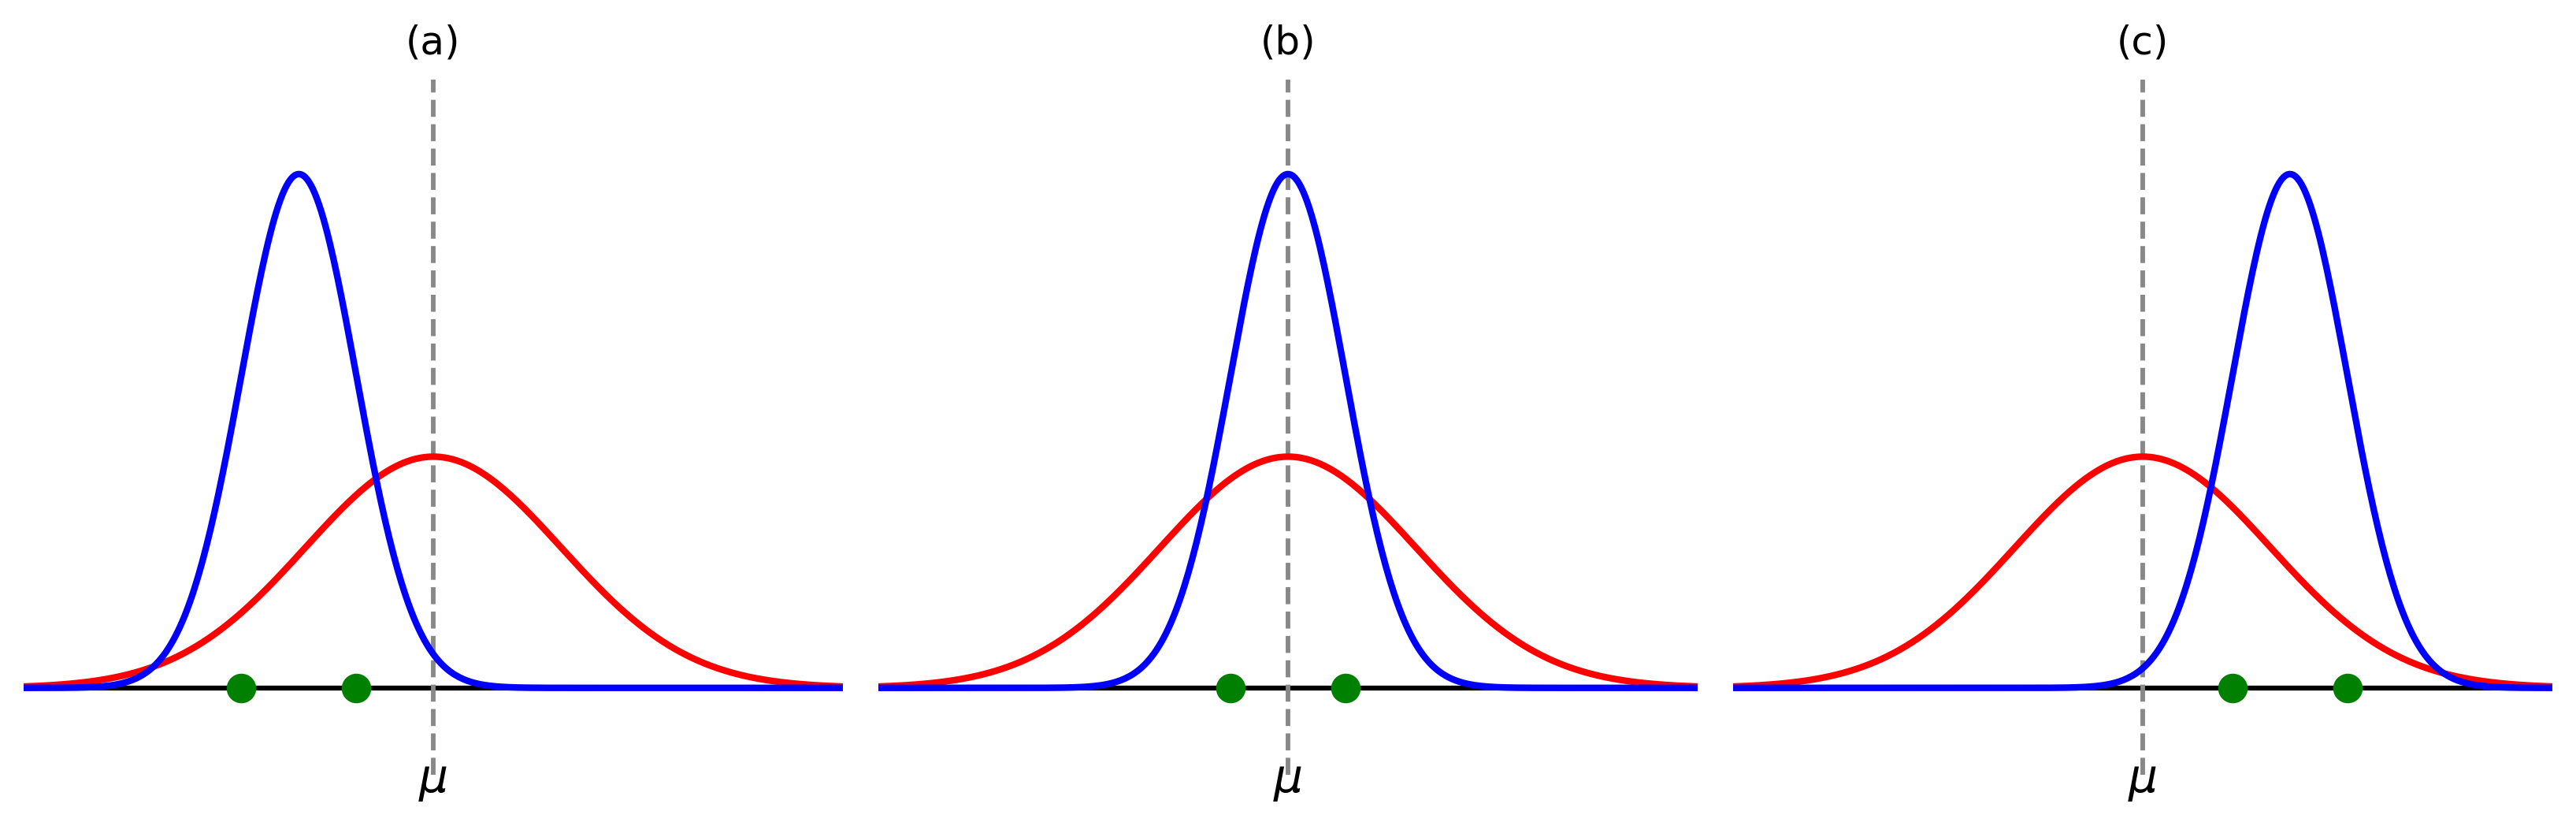

In [7]:
# Figure 2.10 の表示と確認
fig2_10_path = "../result/fig2_10_mle_bias.png"
if os.path.exists(fig2_10_path):
    display(Image(filename=fig2_10_path, width=800))
else:
    from scripts.generate_ch2_3_figures import generate_figure_2_10
    generate_figure_2_10()
    display(Image(filename=fig2_10_path, width=800))


#### 不偏分散推定量（ベッセルの補正）(式 2.62, 2.63)
もし真の平均 $\mu$ が事前に既知であるならば、真の平均まわりで測った分散推定量 $\widehat{\sigma}^2$:
$$
\widehat{\sigma}^2 = \frac{1}{N} \sum_{n=1}^N (x_n - \mu)^2 \tag{2.62}
$$
は期待値 $\mathbb{E}[\widehat{\sigma}^2] = \sigma^2$ となり、偏りはありません。

しかし実際には母平均 $\mu$ は未知であり、データから推定した $\mu_{\mathrm{ML}}$ で代用せざるを得ません。
このとき生じるバイアス係数 $\frac{N-1}{N}$ を補正するため、最尤推定量に $\frac{N}{N-1}$ を乗じた推定量：

$$
\widetilde{\sigma}^2 = \frac{N}{N - 1} \sigma_{\mathrm{ML}}^2 = \frac{1}{N - 1} \sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2 \tag{2.63}
$$

を定義します。これを **不偏分散 (Unbiased Sample Variance)**、分母を $N-1$ とする操作を **ベッセルの補正 (Bessel's Correction)** と呼びます。
$$
\mathbb{E}[\widetilde{\sigma}^2] = \frac{N}{N-1} \mathbb{E}[\sigma_{\mathrm{ML}}^2] = \frac{N}{N-1} \left( \frac{N-1}{N} \sigma^2 \right) = \sigma^2
$$

---

#### 漸近的不偏性と過学習（Overfitting）への接続
サンプル数 $N$ が大きくなる極限では：
$$\lim_{N \to \infty} \frac{N - 1}{N} = 1$$
となるため、最尤分散推定量のバイアスは消失します（**一致性 / 漸近的不偏性**）。
深層学習の大規模データセット（$N \sim 10^5 \sim 10^9$）では、分母 $N$ と $N-1$ の差は実用上無視できます。

しかし、モデルの自由度（パラメータ数 $M$）がデータ数 $N$ に匹敵あるいは凌駕する複雑なモデルでは、この「データに合わせすぎることによる分散・不確実性の過小評価」がまさに **過学習 (Overfitting)** の本質そのものとなります。ベイズ的アプローチ（事前分布の導入）は、まさにこの過学習とバイアスを解消するための処方箋となります。


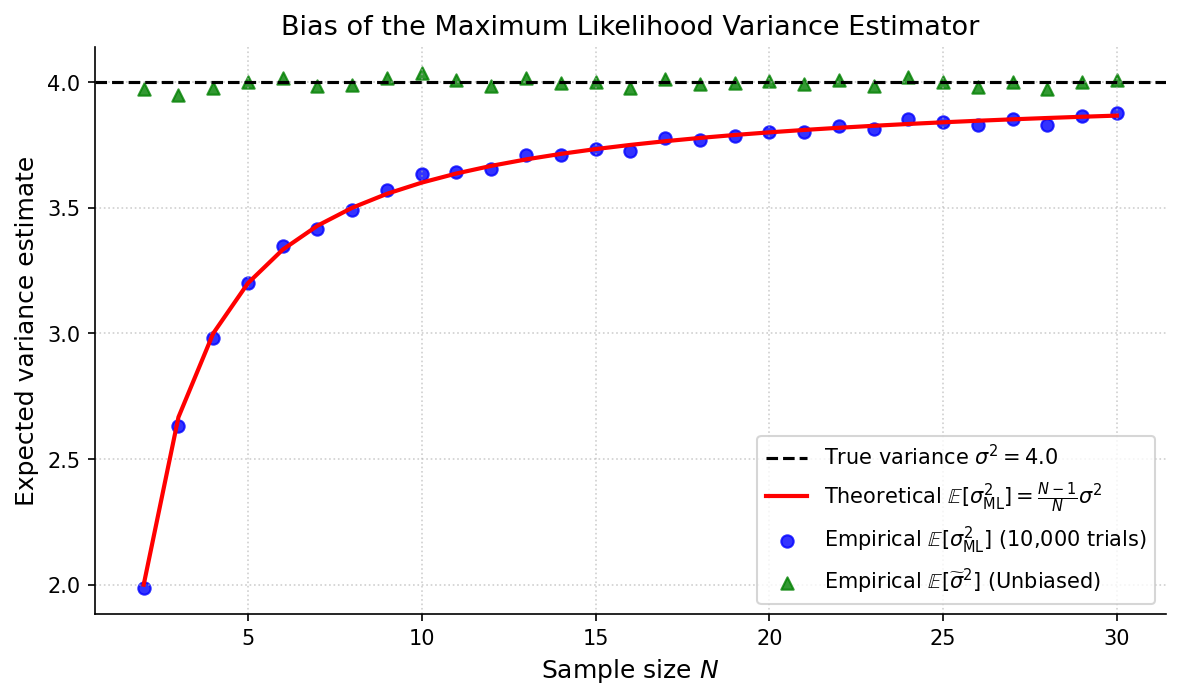

In [8]:
# サンプルサイズ N に対する最尤分散推定バイアスのシミュレーション
true_sigma2 = 4.0
sample_sizes = np.arange(2, 31)
empirical_mle_vars = []
theoretical_mle_vars = []
empirical_unbiased_vars = []

for N_val in sample_sizes:
    sim_res = simulate_gaussian_mle_bias(
        mu=0.0, sigma2=true_sigma2, N=N_val, n_trials=10_000, seed=N_val
    )
    empirical_mle_vars.append(sim_res["E_sigma2_ML"])
    theoretical_mle_vars.append(sim_res["theoretical_E_sigma2_ML"])
    empirical_unbiased_vars.append(sim_res["E_sigma2_tilde"])

plt.figure(figsize=(8, 4.8), dpi=150)
plt.axhline(true_sigma2, color='black', linestyle='--', linewidth=1.5, label=r'True variance $\sigma^2 = 4.0$')
plt.plot(sample_sizes, theoretical_mle_vars, color='red', linestyle='-', linewidth=2.0,
         label=r'Theoretical $\mathbb{E}[\sigma_{\mathrm{ML}}^2] = \frac{N-1}{N}\sigma^2$')
plt.scatter(sample_sizes, empirical_mle_vars, color='blue', s=35, alpha=0.8,
            label=r'Empirical $\mathbb{E}[\sigma_{\mathrm{ML}}^2]$ (10,000 trials)')
plt.scatter(sample_sizes, empirical_unbiased_vars, color='green', marker='^', s=35, alpha=0.8,
            label=r'Empirical $\mathbb{E}[\widetilde{\sigma}^2]$ (Unbiased)')

plt.xlabel('Sample size $N$', fontsize=12)
plt.ylabel('Expected variance estimate', fontsize=12)
plt.title('Bias of the Maximum Likelihood Variance Estimator', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


<a id="sec_2_3_4"></a>
---
### 2.3.4 線形回帰 (Linear regression)

第1章では、入力 $x$ から目標値 $t$ を予測する多項式回帰モデルを「二乗和誤差関数の最小化」というヒューリスティックな最適化問題として導入しました。
本小節では、この回帰問題を **ガウス雑音を仮定した確率論的枠組み (Probabilistic Formulation)** から捉え直します。

#### 1. 条件付きガウス分布モデル (式 2.64, Figure 2.11)
目標変数 $t$ は、入力 $x$ に依存する決定論的関数 $y(x, \mathbf{w})$ に、平均 0、分散 $\sigma^2$ のガウスノイズ $\epsilon \sim \mathcal{N}(0, \sigma^2)$ が加わったものとして生成されるとモデル化します：
$$t = y(x, \mathbf{w}) + \epsilon$$
これは、入力 $x$ が与えられたときの目標値 $t$ の条件付き確率分布が、平均 $y(x, \mathbf{w})$、分散 $\sigma^2$ のガウス分布に従うことを意味します：

$$
p(t \mid x, \mathbf{w}, \sigma^2) = \mathcal{N}(t \mid y(x, \mathbf{w}), \sigma^2) \tag{2.64}
$$

ここで $y(x, \mathbf{w})$ は基底関数の線形結合（第1章では多項式 $\sum_{j=0}^M w_j x^j = \boldsymbol{\phi}(x)^T \mathbf{w}$）です。

この確率的線形回帰の描像が、教科書 **Figure 2.11** です。
モデルは単に入力 $x$ に対する単一のスカラー予測値 $y(x, \mathbf{w})$ を出力するだけでなく、任意の評価点 $x_0$ において、**平均 $y(x_0, \mathbf{w})$、広がり $\sigma$ を持つ確率分布（不確実性）全体** を提供します。


### 教科書図版の再現: Figure 2.11
以下の図は、多項式回帰曲線 $y(x, \mathbf{w})$（赤線）、ノイズを含む観測データ点（青点）、およびテスト点 $x_0$ における目標変数の条件付き確率密度分布 $p(t \mid x_0, \mathbf{w}, \sigma^2)$（垂直方向にプロットされた青いベルカーブ）を再現したものです。

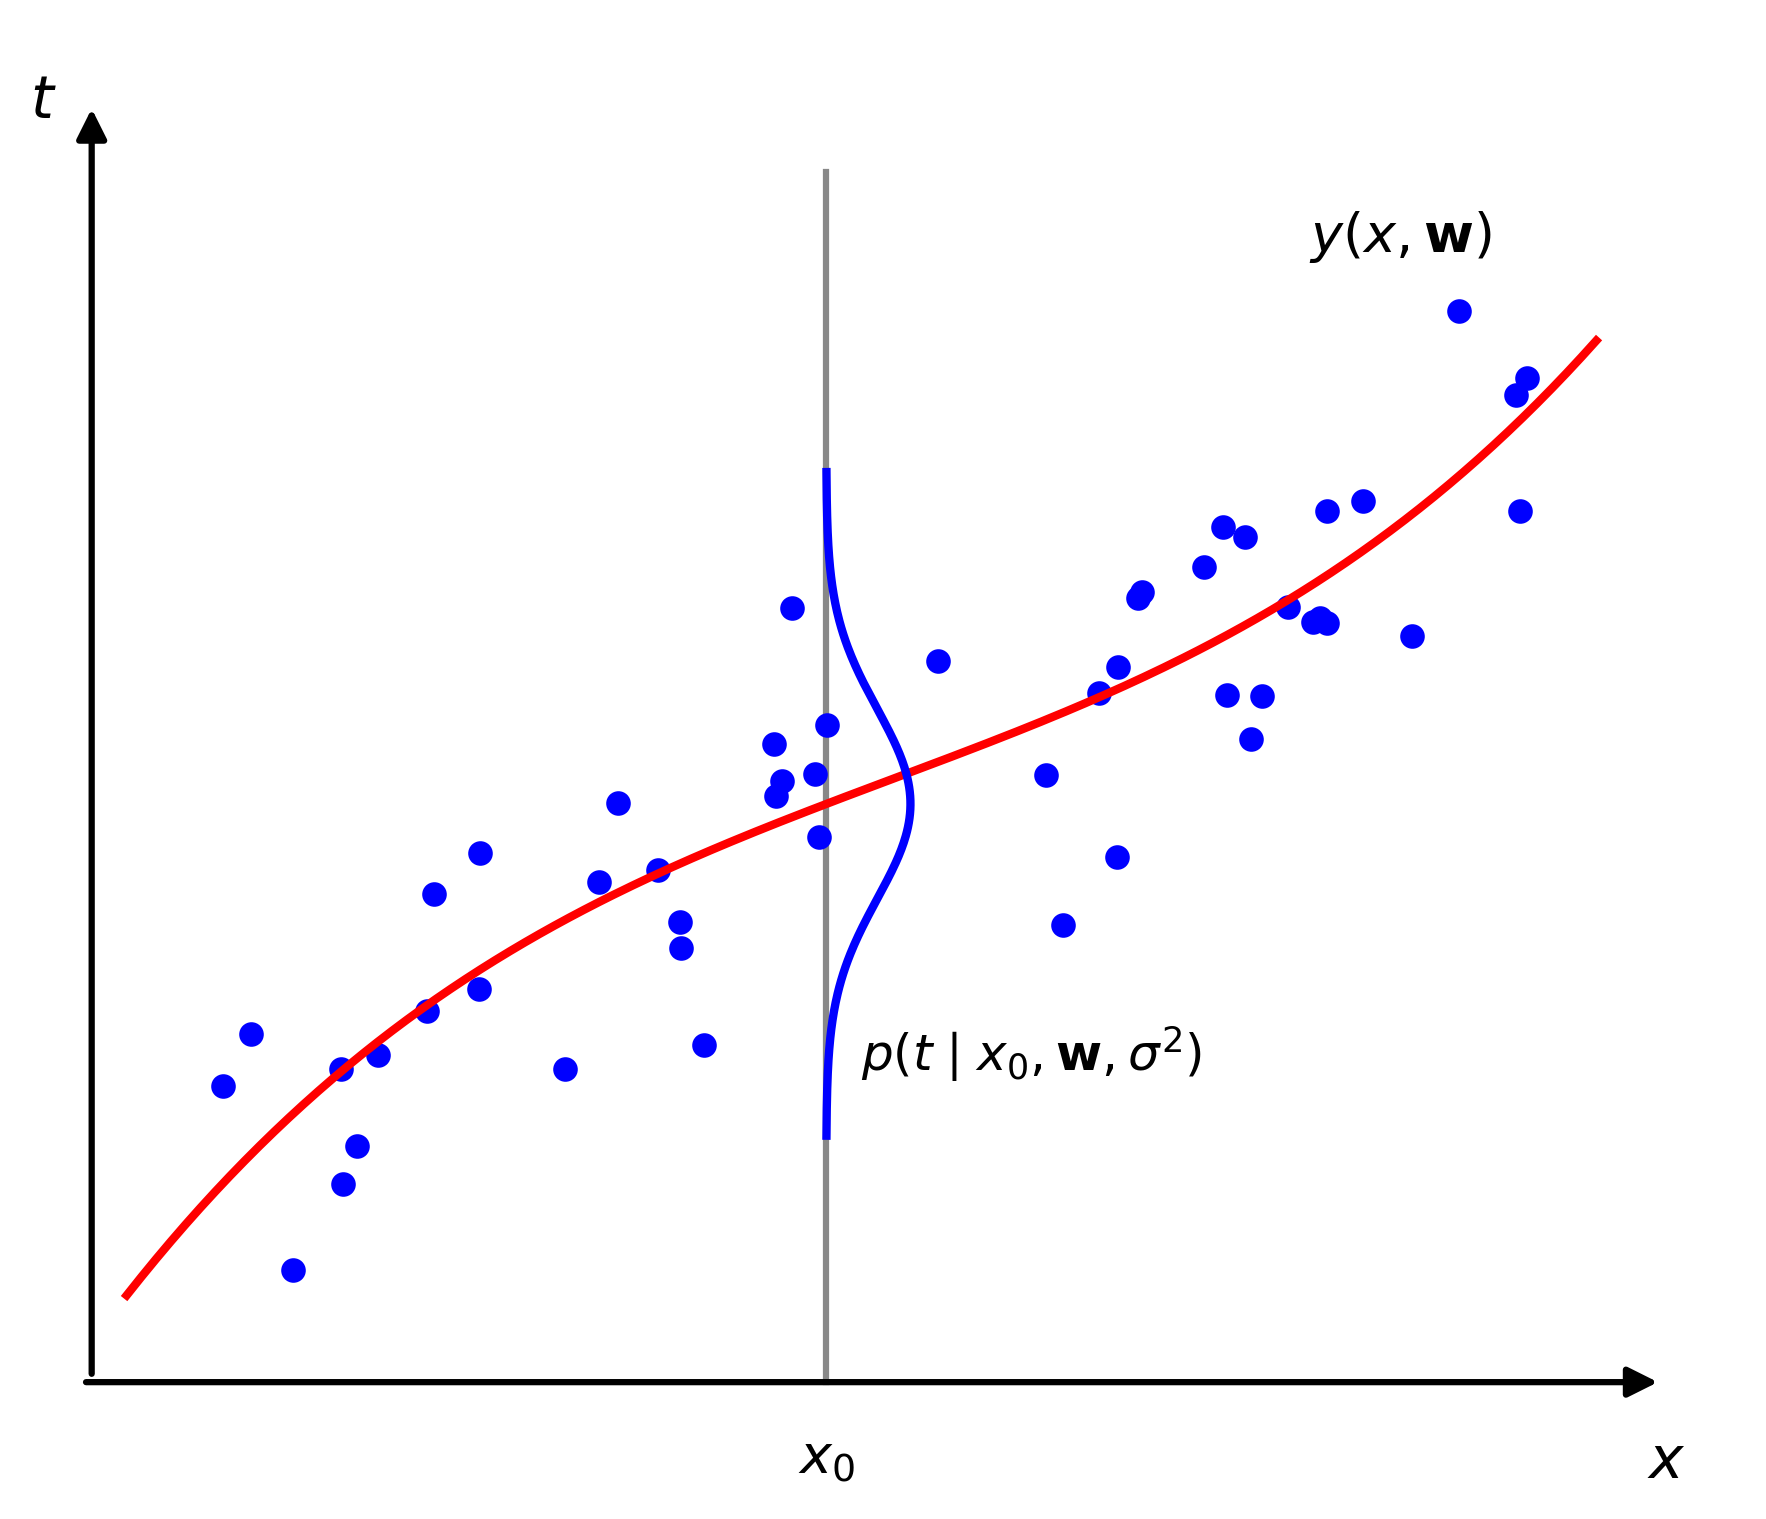

In [9]:
# Figure 2.11 の表示と確認
fig2_11_path = "../result/fig2_11_linear_regression.png"
if os.path.exists(fig2_11_path):
    display(Image(filename=fig2_11_path, width=500))
else:
    from scripts.generate_ch2_3_figures import generate_figure_2_11
    generate_figure_2_11()
    display(Image(filename=fig2_11_path, width=500))


#### 2. 最尤推定と二乗和誤差の等価性 (式 2.65 - 2.67)
独立に観測された訓練データセット $\mathbf{X} = (x_1, \dots, x_N)^T$、$\mathbf{t} = (t_1, \dots, t_N)^T$ に対する同時尤度関数は：

$$
p(\mathbf{t} \mid \mathbf{X}, \mathbf{w}, \sigma^2) = \prod_{n=1}^N \mathcal{N}(t_n \mid y(x_n, \mathbf{w}), \sigma^2) \tag{2.65}
$$

両辺の対数をとると：

$$
\ln p(\mathbf{t} \mid \mathbf{X}, \mathbf{w}, \sigma^2) = -\frac{1}{2\sigma^2} \sum_{n=1}^N \{ y(x_n, \mathbf{w}) - t_n \}^2 - \frac{N}{2} \ln \sigma^2 - \frac{N}{2} \ln(2\pi) \tag{2.66}
$$

この式をパラメータ $\mathbf{w}$ について最大化することを考えます。
右辺において $\mathbf{w}$ に依存するのは第1項のみであり、かつ負の符号がついているため、対数尤度を最大化することは、以下の **二乗和誤差関数 (Sum-of-Squares Error Function)**：

$$
E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \{ y(x_n, \mathbf{w}) - t_n \}^2 \tag{2.67}
$$

**を最小化することと数学的に完全に一致します**。
これにより、第1章で直感的に導入された二乗誤差最小化基準が、「**加法的な独立同一ガウス雑音を仮定した最尤推定**」という自然な確率論的仮定から必然的に導かれることが証明されました。

---

#### 3. パラメータの閉形式解 (式 2.67, 2.68)
デザイン行列 $\boldsymbol{\Phi} \in \mathbb{R}^{N \times (M+1)}$（要素 $\Phi_{nj} = x_n^j$）を用いると、二乗和誤差の勾配をゼロとおくことで、最小二乗解（正規方程式: Normal Equations）が得られます：
$$
\mathbf{w}_{\mathrm{ML}} = (\boldsymbol{\Phi}^T \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \mathbf{t} \tag{2.67}
$$

さらに、対数尤度をノイズ分散 $\sigma^2$ について微分してゼロとおくことで、最尤ノイズ分散推定量が得られます：

$$
\sigma_{\mathrm{ML}}^2 = \frac{1}{N} \sum_{n=1}^N \{ y(x_n, \mathbf{w}_{\mathrm{ML}}) - t_n \}^2 \tag{2.68}
$$
これは、最適化された回帰モデルの「**残差二乗平均**」に一致します。

---

#### 4. 予測分布 (Predictive distribution) (式 2.69)
最尤推定量 $\mathbf{w}_{\mathrm{ML}}$ と $\sigma_{\mathrm{ML}}^2$ を得た後、新たな入力値 $x$ が与えられたときの目標値 $t$ の **予測分布 (Predictive Distribution)** は、以下の条件付きガウス分布として与えられます：

$$
p(t \mid x, \mathbf{w}_{\mathrm{ML}}, \sigma_{\mathrm{ML}}^2) = \mathcal{N}(t \mid y(x, \mathbf{w}_{\mathrm{ML}}), \sigma_{\mathrm{ML}}^2) \tag{2.69}
$$
最尤予測分布は、点予測として平均 $y(x, \mathbf{w}_{\mathrm{ML}})$ を与えるだけでなく、予測のばらつき（信頼区間）として $\pm \sigma_{\mathrm{ML}}$ や $\pm 2\sigma_{\mathrm{ML}}$ の帯域を明示的に提供します。


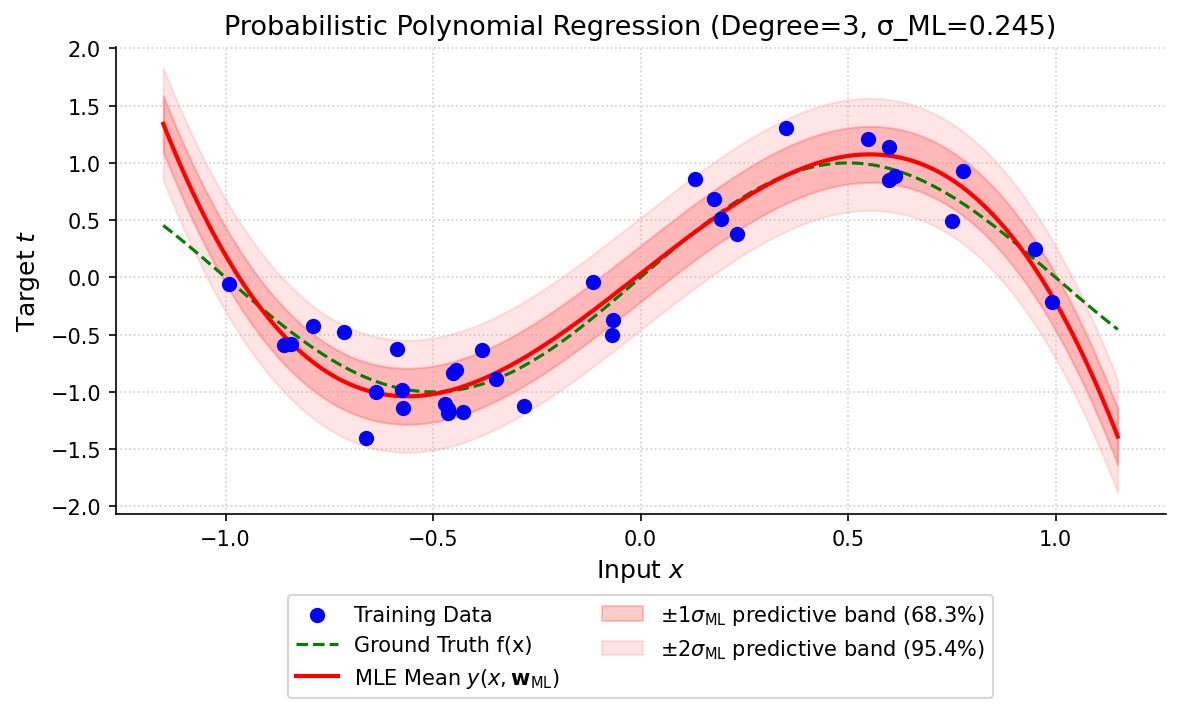

最尤推定重み w_ML: [ 0.03133756  2.84186555 -0.04235163 -3.04702863]
最尤ノイズ分散 sigma2_ML: 0.0600 (推定標準偏差: 0.2450)
二乗和誤差 E(w): 1.0502
対数尤度 ln p(t | X, w, sigma2): -0.4320


In [10]:
# 確率的線形回帰の実装と予測不確実性バンドの可視化
rng = np.random.default_rng(2024)
N_pts = 35
x_train = rng.uniform(-1.0, 1.0, size=N_pts)
true_signal = lambda x: np.sin(np.pi * x)
t_train = true_signal(x_train) + rng.normal(0, 0.25, size=N_pts)

# 多項式回帰モデル (M=3) の最尤フィッティング
model = GaussianLinearRegression(degree=3)
model.fit(x_train, t_train)

# テスト点での予測分布評価
x_test = np.linspace(-1.15, 1.15, 200)
y_pred, sigma_pred = model.predict(x_test)

# プロット
plt.figure(figsize=(8, 5), dpi=150)
plt.scatter(x_train, t_train, color='blue', s=40, zorder=4, label='Training Data')
plt.plot(x_test, true_signal(x_test), color='green', linestyle='--', linewidth=1.5, label='Ground Truth f(x)')
plt.plot(x_test, y_pred, color='red', linewidth=2.0, label=r'MLE Mean $y(x, \mathbf{w}_{\mathrm{ML}})$')

# 1σ および 2σ の予測不確実性バンド
plt.fill_between(x_test, y_pred - sigma_pred, y_pred + sigma_pred, color='red', alpha=0.2,
                 label=r'$\pm 1\sigma_{\mathrm{ML}}$ predictive band (68.3%)')
plt.fill_between(x_test, y_pred - 2 * sigma_pred, y_pred + 2 * sigma_pred, color='red', alpha=0.1,
                 label=r'$\pm 2\sigma_{\mathrm{ML}}$ predictive band (95.4%)')

plt.xlabel('Input $x$', fontsize=12)
plt.ylabel('Target $t$', fontsize=12)
plt.title(f'Probabilistic Polynomial Regression (Degree=3, σ_ML={sigma_pred:.3f})', fontsize=13)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"最尤推定重み w_ML: {model.w}")
print(f"最尤ノイズ分散 sigma2_ML: {model.sigma2_ml:.4f} (推定標準偏差: {model.sigma_ml:.4f})")
print(f"二乗和誤差 E(w): {model.sum_of_squares_error(x_train, t_train):.4f}")
print(f"対数尤度 ln p(t | X, w, sigma2): {model.log_likelihood(x_train, t_train):.4f}")


<a id="sec_summary"></a>
---
## まとめと深層学習への接続

本節（2.3節）で学んだガウス分布とその最尤推定の数理は、現代のディープラーニングアーキテクチャの根幹を支えています：

1. **二乗平均平方根誤差 (MSE Loss) の確率的起源**:
   ニューラルネットワークの回帰タスクで標準的に用いられる平均二乗誤差（MSE）損失関数：
   $$\mathcal{L}_{\mathrm{MSE}}(\boldsymbol{\theta}) = \frac{1}{N}\sum_{n=1}^N \|f_{\boldsymbol{\theta}}(\mathbf{x}_n) - \mathbf{t}_n\|^2$$
   は、ネットワークの出力にガウス雑音を仮定したときの **負の対数尤度 (Negative Log-Likelihood: NLL) の最小化** と厳密に一致します。
2. **不確実性推定と異分散回帰 (Heteroscedastic Regression)**:
   ネットワークの出力層を2分岐させ、平均 $\mu_{\boldsymbol{\theta}}(x)$ だけでなく入力依存の分散 $\sigma^2_{\boldsymbol{\theta}}(x)$ を同時に出力させることで、自動運転や医療診断に必要な **データ内在的不確実性（Aleatoric Uncertainty）** を直接学習できます。
3. **潜在変数モデル（VAE, Diffusion Models）**:
   変分オートエンコーダ（VAE）における潜在空間の事前分布 $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ やエンコーダ $q_{\boldsymbol{\phi}}(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$、拡散モデル（DDPM）の前向き・逆向き遷移核はすべてガウス分布の解析的性質（再パラメータ化トリック、KLダイバージェンスの閉形式解）に基づいています。

---

### 本節で学んだ重要数式一覧

| 概念 | 数式 | 式番号 |
| :--- | :--- | :--- |
| **1次元ガウス分布** | $\mathcal{N}(x \mid \mu, \sigma^2) = \frac{1}{(2\pi\sigma^2)^{1/2}}\exp\left\{ -\frac{(x-\mu)^2}{2\sigma^2} \right\}$ | 式 (2.49) |
| **精度パラメータ** | $\mathcal{N}(x \mid \mu, \beta^{-1}) = \left(\frac{\beta}{2\pi}\right)^{1/2}\exp\left\{ -\frac{\beta}{2}(x-\mu)^2 \right\}$ | 式 (2.50) |
| **期待値（平均）** | $\mathbb{E}[x] = \int \mathcal{N}(x \mid \mu, \sigma^2) x dx = \mu$ | 式 (2.52) |
| **2次モーメント** | $\mathbb{E}[x^2] = \mu^2 + \sigma^2$ | 式 (2.53) |
| **分散** | $\text{var}[x] = \mathbb{E}[x^2] - (\mathbb{E}[x])^2 = \sigma^2$ | 式 (2.54) |
| **同時尤度** | $p(\mathbf{x} \mid \mu, \sigma^2) = \prod_{n=1}^N \mathcal{N}(x_n \mid \mu, \sigma^2)$ | 式 (2.55) |
| **対数尤度** | $\ln p(\mathbf{x} \mid \mu, \sigma^2) = -\frac{1}{2\sigma^2}\sum(x_n-\mu)^2 - \frac{N}{2}\ln\sigma^2 - \frac{N}{2}\ln(2\pi)$ | 式 (2.56) |
| **最尤平均推定量** | $\mu_{\mathrm{ML}} = \frac{1}{N}\sum_{n=1}^N x_n$ | 式 (2.57) |
| **最尤分散推定量** | $\sigma_{\mathrm{ML}}^2 = \frac{1}{N}\sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2$ | 式 (2.58) |
| **平均推定量の不偏性** | $\mathbb{E}[\mu_{\mathrm{ML}}] = \mu$ | 式 (2.59) |
| **分散推定量のバイアス** | $\mathbb{E}[\sigma_{\mathrm{ML}}^2] = \frac{N-1}{N}\sigma^2$ | 式 (2.60) |
| **真平均での分散推定量** | $\mathbb{E}[\widehat{\sigma}^2] = \mathbb{E}\left[\frac{1}{N}\sum(x_n-\mu)^2\right] = \sigma^2$ | 式 (2.62) |
| **不偏分散（ベッセル補正）** | $\widetilde{\sigma}^2 = \frac{N}{N-1}\sigma_{\mathrm{ML}}^2 = \frac{1}{N-1}\sum_{n=1}^N(x_n-\mu_{\mathrm{ML}})^2$ | 式 (2.63) |
| **条件付き線形回帰** | $p(t \mid x, \mathbf{w}, \sigma^2) = \mathcal{N}(t \mid y(x, \mathbf{w}), \sigma^2)$ | 式 (2.64) |
| **二乗和誤差関数** | $E(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^N \{y(x_n, \mathbf{w}) - t_n\}^2$ | 式 (2.67) |
| **最尤ノイズ分散** | $\sigma_{\mathrm{ML}}^2 = \frac{1}{N}\sum_{n=1}^N \{y(x_n, \mathbf{w}_{\mathrm{ML}}) - t_n\}^2$ | 式 (2.68) |
| **予測分布** | $p(t \mid x, \mathbf{w}_{\mathrm{ML}}, \sigma_{\mathrm{ML}}^2) = \mathcal{N}(t \mid y(x, \mathbf{w}_{\mathrm{ML}}), \sigma_{\mathrm{ML}}^2)$ | 式 (2.69) |
